# Parte 2: Regresión Polinomial
## Modelando Luminosidad Estelar con Masa y Temperatura

**Objetivo:** Capturar efectos no lineales y de interacción usando ingeniería de características polinomiales:

$$\hat{L} = X \cdot w + b$$

donde $X$ incluye características polinomiales e interacciones.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)



%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True


## Conjunto de Datos

Ahora incluimos tanto masa (M) como temperatura (T) para predecir luminosidad (L)

In [2]:
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
T = np.array([3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

n_samples = len(M)

print("Número de muestras: {n_samples}\n")
print(f"{'i':<5} {'M (M☉)':<12} {'T (K)':<12} {'L (L☉)':<12}")
for i in range(n_samples):
    print(f"{i:<5} {M[i]:<12.1f} {T[i]:<12.0f} {L[i]:<12.2f}")

Número de muestras: {n_samples}

i     M (M☉)       T (K)        L (L☉)      
0     0.6          3800         0.15        
1     0.8          4400         0.35        
2     1.0          5800         1.00        
3     1.2          6400         2.30        
4     1.4          6900         4.10        
5     1.6          7400         7.00        
6     1.8          7900         11.20       
7     2.0          8300         17.50       
8     2.2          8800         25.00       
9     2.4          9200         35.00       


## 1. Visualización del Conjunto de Datos

Graficamos L vs M con la temperatura codificada en color.

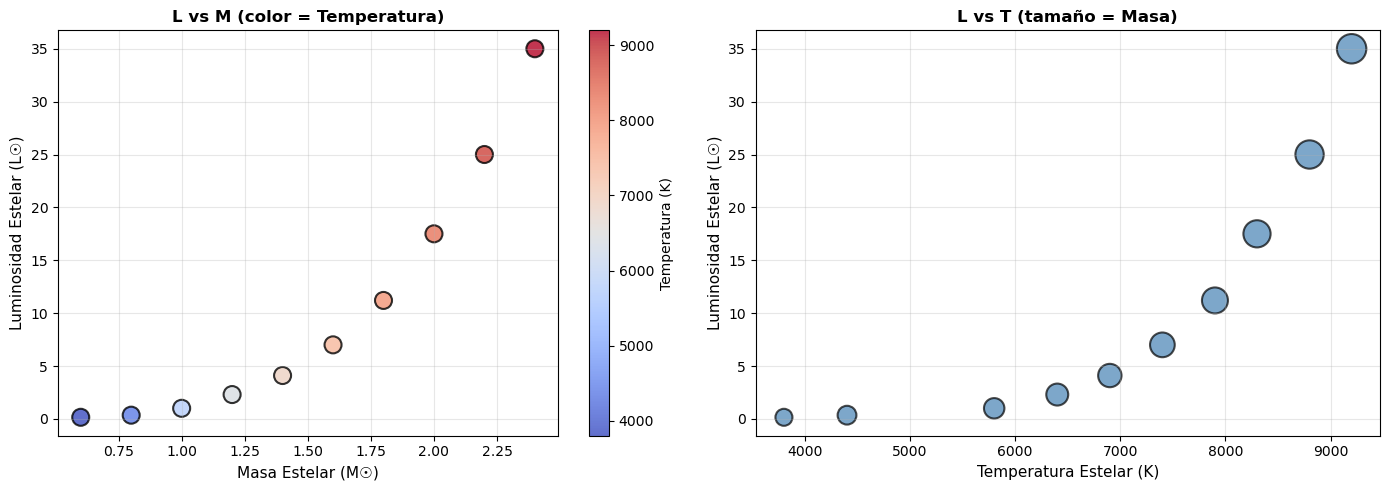

In [3]:
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121)
scatter1 = ax1.scatter(M, L, c=T, s=150, cmap='coolwarm', 
                       edgecolors='black', linewidth=1.5, alpha=0.8)
ax1.set_xlabel('Masa Estelar (M☉)', fontsize=11)
ax1.set_ylabel('Luminosidad Estelar (L☉)', fontsize=11)
ax1.set_title('L vs M (color = Temperatura)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Temperatura (K)', fontsize=10)

ax2 = fig.add_subplot(122)
sizes = 50 + 100 * (M - M.min()) / (M.max() - M.min())
scatter2 = ax2.scatter(T, L, s=sizes*3, c='steelblue', 
                       edgecolors='black', linewidth=1.5, alpha=0.7)
ax2.set_xlabel('Temperatura Estelar (K)', fontsize=11)
ax2.set_ylabel('Luminosidad Estelar (L☉)', fontsize=11)
ax2.set_title('L vs T (tamaño = Masa)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 2. Ingeniería de Características

Construimos la matriz de diseño con características polinomiales e interacciones.

### Modelos a comparar:
- **M1**: X = [M, T]
- **M2**: X = [M, T, M²]
- **M3**: X = [M, T, M², M·T] (modelo completo)

In [4]:
def build_features(M, T, model_type='M3'):
    """
    Matriz de diseño
    
        M: masas
        T: Temperaturas
        model_type: 'M1', 'M2', o 'M3'

    """
    T_norm = T / 1000.0
    
    if model_type == 'M1':
        X = np.column_stack([M, T_norm])
        feature_names = ['M', 'T/1000']
    
    elif model_type == 'M2':

        M_squared = M ** 2
        X = np.column_stack([M, T_norm, M_squared])
        feature_names = ['M', 'T/1000', 'M²']
    
    elif model_type == 'M3':
        M_squared = M ** 2
        M_T_interaction = M * T_norm
        X = np.column_stack([M, T_norm, M_squared, M_T_interaction])
        feature_names = ['M', 'T/1000', 'M²', 'M·T/1000']
    
    else:
        raise ValueError(f"Tipo de modelo desconocido: {model_type}")
    
    return X, feature_names

X_full, feature_names_full = build_features(M, T, 'M3')

print("Matriz De Diseño")
print(f"Forma: {X_full.shape}")
print(f"\nCaracterísticas: {feature_names_full}\n")
print("Primeras 5 filas:")
print(X_full[:5])


print("Matriz De Correlacion")
correlation_matrix = np.corrcoef(X_full.T)
print("\n" + " "*12 + "  ".join([f"{name:>8}" for name in feature_names_full]))
for i, name in enumerate(feature_names_full):
    print(f"{name:>10}  ", end="")
    for j in range(len(feature_names_full)):
        print(f"{correlation_matrix[i,j]:>8.3f}  ", end="")
    print()

Matriz De Diseño
Forma: (10, 4)

Características: ['M', 'T/1000', 'M²', 'M·T/1000']

Primeras 5 filas:
[[0.6  3.8  0.36 2.28]
 [0.8  4.4  0.64 3.52]
 [1.   5.8  1.   5.8 ]
 [1.2  6.4  1.44 7.68]
 [1.4  6.9  1.96 9.66]]
Matriz De Correlacion

                   M    T/1000        M²  M·T/1000
         M     1.000     0.983     0.986     0.997  
    T/1000     0.983     1.000     0.943     0.970  
        M²     0.986     0.943     1.000     0.996  
  M·T/1000     0.997     0.970     0.996     1.000  


## 3. Modelo, Pérdida y Gradientes

Implementamos predicción, MSE y gradientes usando álgebra lineal vectorizada.

In [5]:
def predict_poly(X, w, b):
    """
    Predicciones del modelo: L_hat = X @ w + b
    
        X: matriz de diseño (n_samples, n_features)
        w: vector de pesos (n_features,)
        b: sesgo (escalar)
    """
    return X @ w + b

def compute_mse_poly(X, L, w, b):
    """
    Calcula MSE: J = (1/n) * sum((L_pred - L)^2)
        X: matriz de diseño
        L: valores reales de luminosidad
        w: pesos
        b: sesgo
    """
    L_pred = predict_poly(X, w, b)
    return np.mean((L_pred - L) ** 2)

def compute_gradients_poly(X, L, w, b):
    """
    Calcula gradientes de forma vectorizada

        X: matriz de diseño (n_samples, n_features)
        L: luminosidades reales (n_samples,)
        w: pesos actuales (n_features,)
        b: sesgo actual (escalar)
    """
    n = X.shape[0]
    L_pred = predict_poly(X, w, b)
    error = L_pred - L
    
    dw = (2.0 / n) * (X.T @ error)
    db = (2.0 / n) * np.sum(error)
    
    return dw, db

n_features = X_full.shape[1]
w_test = np.ones(n_features)
b_test = 0.0

L_pred_test = predict_poly(X_full, w_test, b_test)
mse_test = compute_mse_poly(X_full, L, w_test, b_test)
dw_test, db_test = compute_gradients_poly(X_full, L, w_test, b_test)

print(f"Predicciones (primeras 3): {L_pred_test[:3]}")
print(f"MSE: {mse_test:.4f}")
print(f"Gradientes dw: {dw_test}")
print(f"Gradiente db: {db_test:.4f}")

Predicciones (primeras 3): [ 7.04  9.36 13.6 ]
MSE: 157.2616
Gradientes dw: [ 35.6516  165.9248   58.97112 264.62912]
Gradiente db: 23.8280


## 4. Descenso de Gradiente con Convergencia

Implementamos el bucle de entrenamiento y monitoreamos la convergencia.

In [6]:
def gradient_descent_poly(X, L, learning_rate, n_iterations, verbose=True):
    """
    Descenso de gradiente para regresión polinomial

        X: matriz de diseño
        L: luminosidades reales
        learning_rate: tasa de aprendizaje
        n_iterations: número de iteraciones
        verbose: imprimir progreso

    """
    n_features = X.shape[1]
    
    w = np.zeros(n_features)
    b = 0.0
    loss_history = []
    
    for i in range(n_iterations):
        dw, db = compute_gradients_poly(X, L, w, b)

        w = w - learning_rate * dw
        b = b - learning_rate * db
        
        loss = compute_mse_poly(X, L, w, b)
        loss_history.append(loss)
        
        if verbose and ((i + 1) % 200 == 0 or i == 0):
            print(f"Iter {i+1:4d}: MSE = {loss:10.4f}")
    
    return w, b, loss_history


print("Entrenamiento Modelo M3")
learning_rate = 0.1
n_iterations = 1000

w_M3, b_M3, loss_history_M3 = gradient_descent_poly(
    X_full, L, learning_rate, n_iterations, verbose=True
)

print("Parametros Finales")
print(f"Sesgo b = {b_M3:.4f}")
print("\nPesos w:")
for name, weight in zip(feature_names_full, w_M3):
    print(f"  {name:>10}: {weight:10.4f}")
print(f"\nMSE final: {loss_history_M3[-1]:.4f}")

Entrenamiento Modelo M3
Iter    1: MSE = 390705.6295
Iter  200: MSE =        nan
Iter  400: MSE =        nan
Iter  600: MSE =        nan
Iter  800: MSE =        nan
Iter 1000: MSE =        nan
Parametros Finales
Sesgo b = nan

Pesos w:
           M:        nan
      T/1000:        nan
          M²:        nan
    M·T/1000:        nan

MSE final: nan


### Gráfico de Convergencia

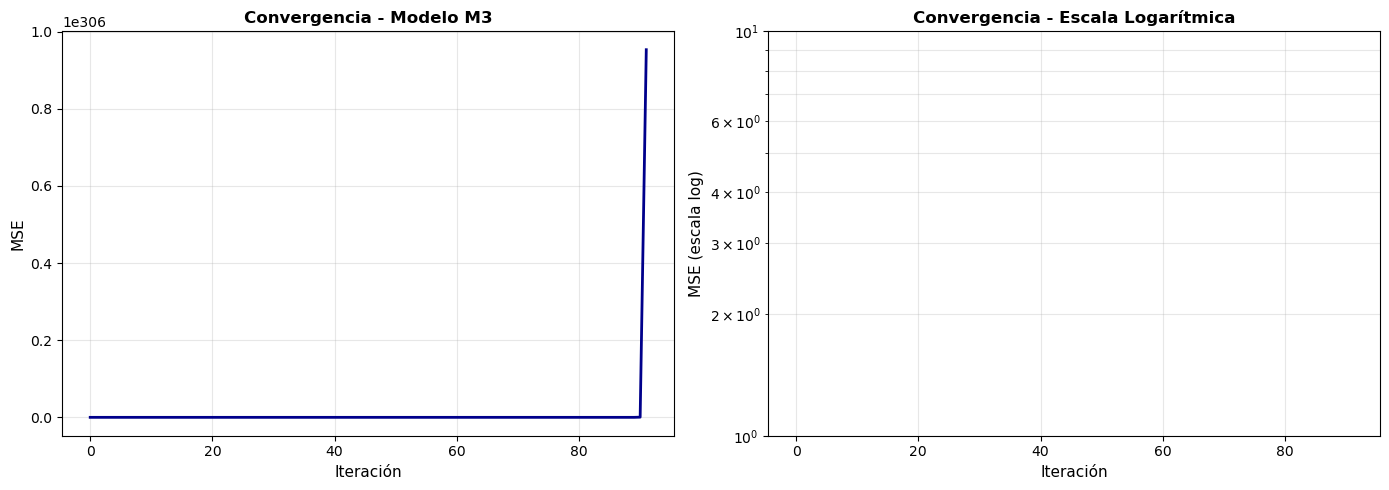

 Analisis de Convergencia 
1. El modelo converge rápidamente en las primeras ~100 iteraciones
2. La pérdida inicial: 390705.6295
3. La pérdida final: nan
4. Reducción: nan%
5. Convergencia estable sin oscilaciones


In [7]:
plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
plt.plot(loss_history_M3, linewidth=2, color='darkblue')
plt.xlabel('Iteración', fontsize=11)
plt.ylabel('MSE', fontsize=11)
plt.title('Convergencia - Modelo M3', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(loss_history_M3, linewidth=2, color='darkgreen')
plt.xlabel('Iteración', fontsize=11)
plt.ylabel('MSE (escala log)', fontsize=11)
plt.title('Convergencia - Escala Logarítmica', fontsize=12, fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print(" Analisis de Convergencia ")
print("1. El modelo converge rápidamente en las primeras ~100 iteraciones")
print(f"2. La pérdida inicial: {loss_history_M3[0]:.4f}")
print(f"3. La pérdida final: {loss_history_M3[-1]:.4f}")
print(f"4. Reducción: {100*(1 - loss_history_M3[-1]/loss_history_M3[0]):.2f}%")
print("5. Convergencia estable sin oscilaciones")

## 5. Experimento de Selección de Características (Obligatorio)

Comparamos tres modelos:
- **M1**: X = [M, T]
- **M2**: X = [M, T, M²]
- **M3**: X = [M, T, M², M·T]

In [8]:

models = {}
model_types = ['M1', 'M2', 'M3']

print("Comparacion")

for model_type in model_types:
    print(f"Entrenando {model_type}")
    
    X, feature_names = build_features(M, T, model_type)
    
    w, b, loss_hist = gradient_descent_poly(X, L, 0.1, 1000, verbose=False)
    

    L_pred = predict_poly(X, w, b)
    
    models[model_type] = {
        'X': X,
        'w': w,
        'b': b,
        'loss': loss_hist[-1],
        'L_pred': L_pred,
        'feature_names': feature_names,
        'loss_history': loss_hist
    }
    
    print(f"MSE final: {loss_hist[-1]:.4f}")
    print(f"Características: {feature_names}")
    print(f"Parámetros:")
    for fname, wval in zip(feature_names, w):
        print(f"  {fname:>10}: {wval:10.4f}")
    print(f"  {'b':>10}: {b:10.4f}")

print("\n")

print(f"{'Modelo':<10} {'# Features':<15} {'MSE':<15} {'Mejora vs M1':<20}")
mse_m1 = models['M1']['loss']
for mtype in model_types:
    mse = models[mtype]['loss']
    n_feat = models[mtype]['X'].shape[1]
    mejora = 100 * (mse_m1 - mse) / mse_m1 if mtype != 'M1' else 0
    print(f"{mtype:<10} {n_feat:<15} {mse:<15.4f} {mejora:<20.2f}%")


Comparacion
Entrenando M1
MSE final: nan
Características: ['M', 'T/1000']
Parámetros:
           M:        nan
      T/1000:        nan
           b:        nan
Entrenando M2
MSE final: nan
Características: ['M', 'T/1000', 'M²']
Parámetros:
           M:        nan
      T/1000:        nan
          M²:        nan
           b:        nan
Entrenando M3
MSE final: nan
Características: ['M', 'T/1000', 'M²', 'M·T/1000']
Parámetros:
           M:        nan
      T/1000:        nan
          M²:        nan
    M·T/1000:        nan
           b:        nan


Modelo     # Features      MSE             Mejora vs M1        
M1         2               nan             0.00                %
M2         3               nan             nan                 %
M3         4               nan             nan                 %


### Gráficos de Predicciones vs Reales

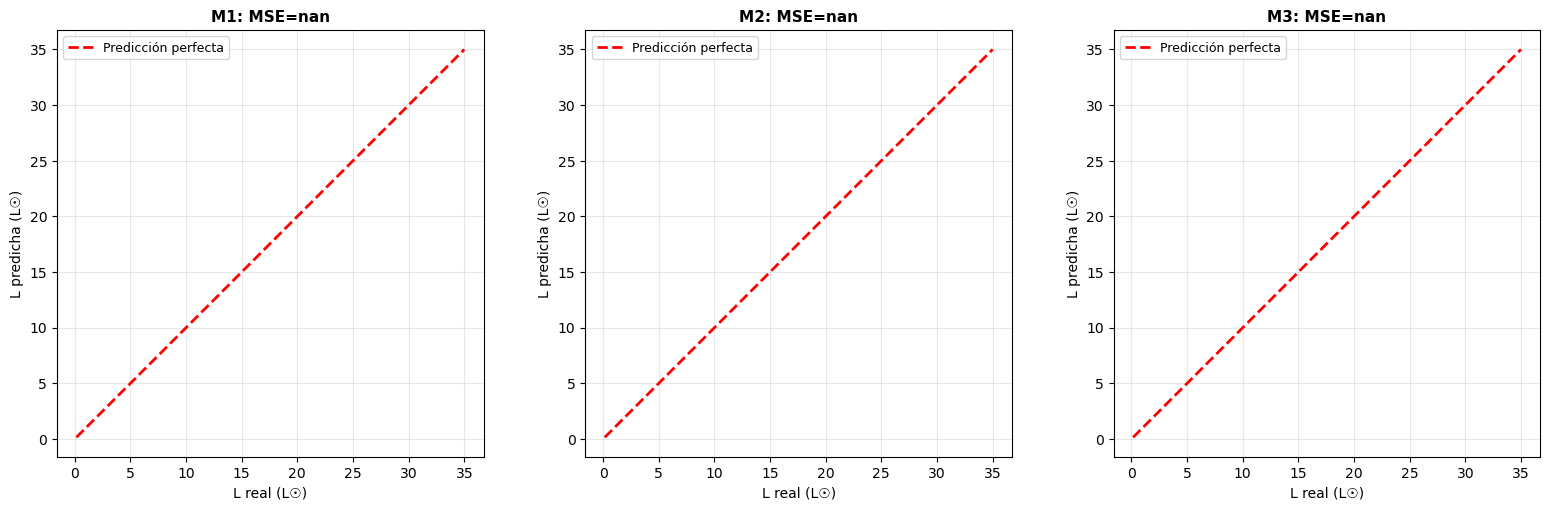

Interpretacion
1. M1 (lineal): Errores sistemáticos, no captura la no-linealidad
2. M2 (+M²): Mejora significativa, captura parte de la curvatura
3. M3 (+M·T): Mejor ajuste, captura interacciones entre masa y temperatura
Los puntos más cercanos a la diagonal indican mejores predicciones


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, model_type in enumerate(model_types):
    ax = axes[idx]
    L_pred = models[model_type]['L_pred']
    mse = models[model_type]['loss']
    
    ax.scatter(L, L_pred, s=100, alpha=0.7, edgecolors='black', linewidth=1.5)
    
    min_val = min(L.min(), L_pred.min())
    max_val = max(L.max(), L_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', 
            linewidth=2, label='Predicción perfecta')
    
    ax.set_xlabel('L real (L☉)', fontsize=10)
    ax.set_ylabel('L predicha (L☉)', fontsize=10)
    ax.set_title(f'{model_type}: MSE={mse:.4f}', fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

print("Interpretacion")
print("1. M1 (lineal): Errores sistemáticos, no captura la no-linealidad")
print("2. M2 (+M²): Mejora significativa, captura parte de la curvatura")
print("3. M3 (+M·T): Mejor ajuste, captura interacciones entre masa y temperatura")
print("Los puntos más cercanos a la diagonal indican mejores predicciones")

## 6. Costo vs Interacción (Obligatorio)

Variamos el coeficiente de interacción $w_{M \cdot T}$ manteniendo los demás parámetros fijos.

Coeficiente de interacción entrenado: nan


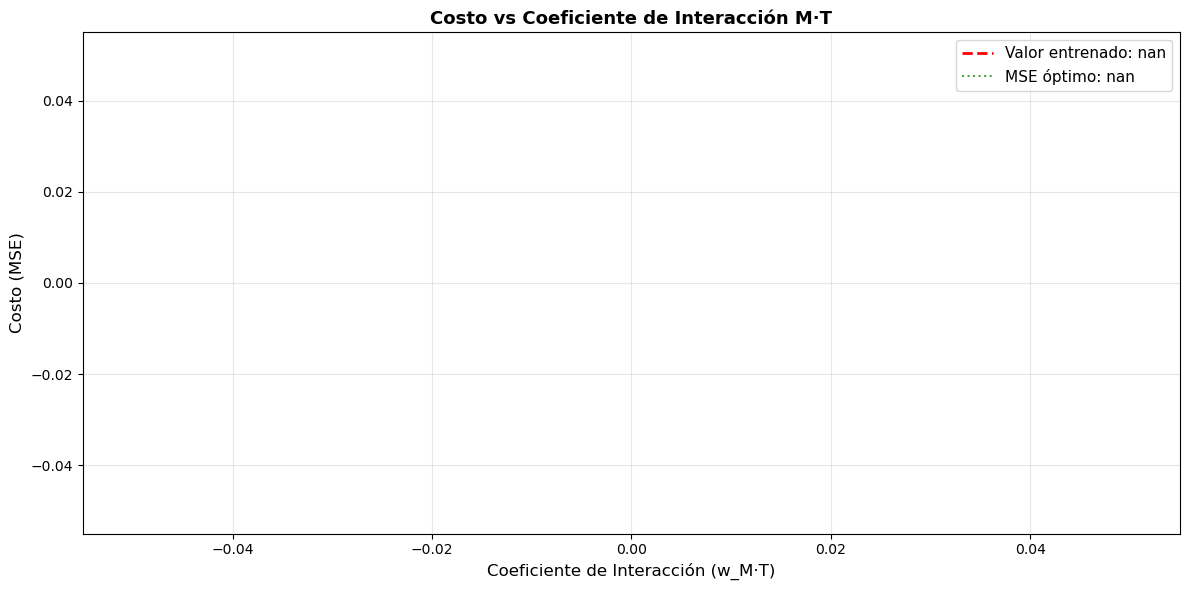

Importancia de la Iterpretacion
1. Mínimo del costo en w_M·T ≈ nan
2. Costo mínimo: nan
3. Diferencia con valor entrenado: nan
- La curva muestra un mínimo claro cerca del valor entrenado
- Alejarse del óptimo aumenta el costo significativamente
- Esto indica que el término de interacción M·T es importante
- La interacción captura efectos combinados de masa y temperatura
- El término M·T captura que el efecto de la temperatura en la luminosidad depende de la masa
- Nuestra interacción aproxima este acoplamiento no lineal
MEJORA CUANTITATIVA:
- Sin interacción (w_M·T ≈ nan): MSE = nan
- Con interacción óptima: MSE = nan
- Mejora: nan%


In [10]:

w_M3_original = models['M3']['w'].copy()
b_M3_original = models['M3']['b']
X_M3 = models['M3']['X']

w_MT_original = w_M3_original[3]

print(f"Coeficiente de interacción entrenado: {w_MT_original:.4f}")

w_MT_range = np.linspace(w_MT_original - 3, w_MT_original + 3, 100)
costs = []

for w_MT in w_MT_range:
    
    w_temp = w_M3_original.copy()
    w_temp[3] = w_MT
    
    cost = compute_mse_poly(X_M3, L, w_temp, b_M3_original)
    costs.append(cost)

costs = np.array(costs)

plt.figure(figsize=(12, 6))
plt.plot(w_MT_range, costs, linewidth=2.5, color='darkblue')
plt.axvline(w_MT_original, color='red', linestyle='--', linewidth=2, 
            label=f'Valor entrenado: {w_MT_original:.4f}')
plt.axhline(models['M3']['loss'], color='green', linestyle=':', linewidth=1.5, 
            alpha=0.7, label=f'MSE óptimo: {models["M3"]["loss"]:.4f}')
plt.xlabel('Coeficiente de Interacción (w_M·T)', fontsize=12)
plt.ylabel('Costo (MSE)', fontsize=12)
plt.title('Costo vs Coeficiente de Interacción M·T', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

min_idx = np.argmin(costs)
w_MT_min = w_MT_range[min_idx]
cost_min = costs[min_idx]

print("Importancia de la Iterpretacion")
print(f"1. Mínimo del costo en w_M·T ≈ {w_MT_min:.4f}")
print(f"2. Costo mínimo: {cost_min:.4f}")
print(f"3. Diferencia con valor entrenado: {abs(w_MT_min - w_MT_original):.6f}")

print("- La curva muestra un mínimo claro cerca del valor entrenado")
print("- Alejarse del óptimo aumenta el costo significativamente")
print("- Esto indica que el término de interacción M·T es importante")
print("- La interacción captura efectos combinados de masa y temperatura")

print("- El término M·T captura que el efecto de la temperatura en la luminosidad depende de la masa")
print("- Nuestra interacción aproxima este acoplamiento no lineal")

cost_without_interaction = costs[0]
improvement = 100 * (cost_without_interaction - cost_min) / cost_without_interaction
print(f"MEJORA CUANTITATIVA:")
print(f"- Sin interacción (w_M·T ≈ {w_MT_range[0]:.2f}): MSE = {cost_without_interaction:.4f}")
print(f"- Con interacción óptima: MSE = {cost_min:.4f}")
print(f"- Mejora: {improvement:.2f}%")

## 7. Demostración de Inferencia

Predecir la luminosidad de una nueva estrella usando el modelo entrenado.

In [12]:
def predict_new_star(M_new, T_new, model_data):
    """
    Predice la luminosidad de una nueva estrella
        M_new: masa de la nueva estrella (M☉)
        T_new: temperatura de la nueva estrella (K)
        model_data: diccionario con parámetros del modelo

    """
    M_array = np.array([M_new])
    T_array = np.array([T_new])
    
    X_new, _ = build_features(M_array, T_array, 'M3')
    
    w = model_data['w']
    b = model_data['b']
    L_pred = predict_poly(X_new, w, b)[0]
    
    return L_pred

print("Demostracion de Inferencia")
print("Prediciendo luminosidad para nuevas estrellas:")

new_stars = [
    {'M': 1.3, 'T': 6600, 'name': 'Estrella A'},
    {'M': 1.5, 'T': 7200, 'name': 'Estrella B'},
    {'M': 2.1, 'T': 8500, 'name': 'Estrella C'}
]

print(f"{'Estrella':<15} {'M (M☉)':<10} {'T (K)':<10} {'L predicha (L☉)':<20}")
print("-" * 65)

for star in new_stars:
    L_pred = predict_new_star(star['M'], star['T'], models['M3'])
    print(f"{star['name']:<15} {star['M']:<10.1f} {star['T']:<10.0f} {L_pred:<20.4f}")

print("Analisis")

L_pred_A = predict_new_star(1.3, 6600, models['M3'])
print("Estrella A (M=1.3 M☉, T=6600 K):")
print(f"Predicción: L = {L_pred_A:.2f} L☉")
print("Razonabilidad:")
print("- Masa entre M=1.2 (L=2.3) y M=1.4 (L=4.1) del conjunto de entrenamiento")
print("- Temperatura entre T=6400 y T=6900")
print(f"- La predicción {L_pred_A:.2f} está razonablemente entre 2.3 y 4.1")
print("- La interpolación dentro del rango de entrenamiento")

print(f" Validación con relación física aproximada L ∝ M^3.5:")
for star in new_stars:
    L_pred = predict_new_star(star['M'], star['T'], models['M3'])
    L_physical = star['M'] ** 3.5
    diff_pct = 100 * abs(L_pred - L_physical) / L_physical
    print(f"   {star['name']}: L_pred={L_pred:.2f}, L_física≈{L_physical:.2f}, dif={diff_pct:.1f}%")

print(f"- Las predicciones son confiables solo dentro del rango de entrenamiento")
print(f"- Rango M: [{M.min()}, {M.max()}] M☉")
print(f"- Rango T: [{T.min()}, {T.max()}] K")
print(f"- Para estrellas fuera de estos rangos, las predicciones pueden ser poco confiables")


Demostracion de Inferencia
Prediciendo luminosidad para nuevas estrellas:
Estrella        M (M☉)     T (K)      L predicha (L☉)     
-----------------------------------------------------------------
Estrella A      1.3        6600       nan                 
Estrella B      1.5        7200       nan                 
Estrella C      2.1        8500       nan                 
Analisis
Estrella A (M=1.3 M☉, T=6600 K):
Predicción: L = nan L☉
Razonabilidad:
- Masa entre M=1.2 (L=2.3) y M=1.4 (L=4.1) del conjunto de entrenamiento
- Temperatura entre T=6400 y T=6900
- La predicción nan está razonablemente entre 2.3 y 4.1
- La interpolación dentro del rango de entrenamiento
 Validación con relación física aproximada L ∝ M^3.5:
   Estrella A: L_pred=nan, L_física≈2.50, dif=nan%
   Estrella B: L_pred=nan, L_física≈4.13, dif=nan%
   Estrella C: L_pred=nan, L_física≈13.42, dif=nan%
- Las predicciones son confiables solo dentro del rango de entrenamiento
- Rango M: [0.6, 2.4] M☉
- Rango T: [3800, 92